# Tissue clustering heatmaps for GTEx, PaxDb, and TCGA expression/abundance data

R notebook translation of Sections 7-8 of `filtering_source_exploration.ipynb`:

7. Within-source hierarchical clustering of tissues (Spearman correlation)
8. Top 50 most variable genes/proteins, hierarchically clustered

Extended with a **TCGA** section (per-cohort median expression, computed
from the raw per-sample STAR-TPM matrices cached by `download_TCGA.py`),
mirroring the GTEx/PaxDb top-variable-gene heatmaps.

In [2]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(readr)
  library(tibble)
  library(data.table)
  library(matrixStats)
  library(pheatmap)
  library(RColorBrewer)
  library(grid)
  library(ggplot2)
  library(patchwork)
})

In [8]:
REPO_ROOT     <- normalizePath("/nfs/home/students/m.tan/BA")
EXPR_FILE     <- file.path(REPO_ROOT, "data", "median_tpm_by_tissue.gct")
PAXDB_FILE    <- file.path(REPO_ROOT, "data", "paxdb_all_tissues.tsv")
UBERON_GROUPS_FILE <- file.path(REPO_ROOT, "data", "tissue_uberon_groups.tsv")
TCGA_RAW_DIR  <- file.path(REPO_ROOT, "data", "tcga_raw")

OUT_ROOT      <- file.path(REPO_ROOT, "sanity_check_outputs")
GTEX_OUT      <- file.path(OUT_ROOT, "gtex")
PAXDB_OUT     <- file.path(OUT_ROOT, "paxdb")
TCGA_OUT      <- file.path(OUT_ROOT, "tcga")
dir.create(OUT_ROOT, showWarnings = FALSE)
dir.create(GTEX_OUT, showWarnings = FALSE)
dir.create(PAXDB_OUT, showWarnings = FALSE)
dir.create(TCGA_OUT, showWarnings = FALSE)

In [9]:
# -- Shared color scales (declared once, reused by every heatmap below) ------

VALUE_PALETTE <- colorRampPalette(brewer.pal(9, "YlGnBu"))          # raw/log10 value heatmaps
CORR_PALETTE  <- colorRampPalette(c("#3B4CC0", "white", "#B40426")) # correlation heatmaps
SOURCE_COLORS <- c(PaxDb = "#FF7F0E", GTEx = "#1F77B4")             # GTEx vs. PaxDb annotation

## Data loading — GTEx and PaxDb

In [10]:
# GTEx GCT: header on line 3, genes x tissues, median TPM. Duplicate gene
# symbols are collapsed with the row-wise median (matches the Python notebook).
read_gtex_median_tpm <- function(path) {
  raw <- read_tsv(path, skip = 2, show_col_types = FALSE) %>%
    rename(ensembl = Name, symbol = Description)
  tissue_cols <- setdiff(colnames(raw), c("ensembl", "symbol"))

  raw %>%
    group_by(symbol) %>%
    summarise(across(all_of(tissue_cols), \(x) median(x, na.rm = TRUE)), .groups = "drop") %>%
    column_to_rownames("symbol") %>%
    as.matrix()
}

# PaxDb wide TSV: id + one column per tissue, ppm. Missing entries mean
# "not detected" (~0 abundance), not "unknown", so fill rather than drop.
read_paxdb <- function(path) {
  mat <- read_tsv(path, show_col_types = FALSE) %>%
    column_to_rownames("id") %>%
    as.matrix()
  mat[is.na(mat)] <- 0
  mat
}

gtex_mat  <- read_gtex_median_tpm(EXPR_FILE)
paxdb_mat <- read_paxdb(PAXDB_FILE)

gtex_log  <- log2(gtex_mat + 1)
paxdb_log <- log2(paxdb_mat + 1)

## Data loading — TCGA

`download_TCGA.py` caches one raw STAR-TPM matrix per cohort in
`data/tcga_raw/` (genes x samples, GDC hub convention: values are
**log2(TPM + 1)**, not linear TPM). There is no pre-aggregated
median-per-cohort matrix the way `median_tpm_by_tissue.gct` exists for
GTEx, so it is built here: each cohort file is collapsed to a single
median-expression column, giving a genes x cohorts matrix analogous to
`gtex_mat`.

The median is taken directly on the log2(TPM + 1) values rather than in
linear TPM space, since the median commutes with any monotonic transform
(`median(log2(x + 1)) == log2(median(x) + 1)`) — this avoids exponentiating
every one of the ~60,000 x (samples) values per cohort just to re-log them
afterwards. Rows are also keyed by bare Ensembl gene ID (version and
`_PAR_Y` suffixes stripped); the handful of genes this collapses onto the
same ID (pseudoautosomal-region duplicates) are combined the same way
`read_gtex_median_tpm()` combines duplicate gene symbols, via row-wise
median.

Reading all 33 cohorts (the largest, BRCA, is ~340 MB gzipped) takes a
while — per the login banner, run this via `sbatch` rather than directly
on the login node.

In [5]:
read_tcga_cohort_median_log <- function(path) {
  dt  <- fread(cmd = paste("zcat", shQuote(path)), header = TRUE)
  ids <- sub("\\..*$", "", dt[[1]])                 # drop Ensembl version / _PAR_Y suffix
  mat <- as.matrix(dt[, -1, with = FALSE])
  med <- rowMedians(mat, na.rm = TRUE)
  tapply(med, ids, median)                          # collapse PAR_Y duplicates onto base ID
}

tcga_files   <- list.files(TCGA_RAW_DIR, pattern = "^TCGA-.*\\.star_tpm\\.tsv\\.gz$", full.names = TRUE)
tcga_cohorts <- sub("^TCGA-(.*)\\.star_tpm\\.tsv\\.gz$", "\\1", basename(tcga_files))

tcga_cohort_medians <- vector("list", length(tcga_files))
names(tcga_cohort_medians) <- tcga_cohorts
for (i in seq_along(tcga_files)) {
  message(sprintf("[%d/%d] TCGA-%s", i, length(tcga_files), tcga_cohorts[i]))
  tcga_cohort_medians[[i]] <- read_tcga_cohort_median_log(tcga_files[i])
}

tcga_common_genes <- Reduce(intersect, lapply(tcga_cohort_medians, names))
tcga_log <- do.call(cbind, lapply(tcga_cohort_medians, `[`, tcga_common_genes))
rownames(tcga_log) <- tcga_common_genes
colnames(tcga_log) <- tcga_cohorts


[1/33] TCGA-ACC

[2/33] TCGA-BLCA

[3/33] TCGA-BRCA

[4/33] TCGA-CESC

[5/33] TCGA-CHOL

[6/33] TCGA-COAD

[7/33] TCGA-DLBC

[8/33] TCGA-ESCA

[9/33] TCGA-GBM

[10/33] TCGA-HNSC

[11/33] TCGA-KICH

[12/33] TCGA-KIRC

[13/33] TCGA-KIRP

[14/33] TCGA-LAML

[15/33] TCGA-LGG

[16/33] TCGA-LIHC

[17/33] TCGA-LUAD

[18/33] TCGA-LUSC

[19/33] TCGA-MESO

[20/33] TCGA-OV

[21/33] TCGA-PAAD

[22/33] TCGA-PCPG

[23/33] TCGA-PRAD

[24/33] TCGA-READ

[25/33] TCGA-SARC

[26/33] TCGA-SKCM

[27/33] TCGA-STAD

[28/33] TCGA-TGCT

[29/33] TCGA-THCA

[30/33] TCGA-THYM

[31/33] TCGA-UCEC

[32/33] TCGA-UCS

[33/33] TCGA-UVM



## Tissue grouping — GTEx and PaxDb (UBERON)

In [12]:
# Tissue -> group assignments come from group_tissues_uberon.py, which climbs
# each tissue's UBERON is_a/part_of ancestry to the nearest organ-level term
# (e.g. every GTEx "Brain - ..." subregion and PaxDb's BRAIN/CEREBRAL_CORTEX/
# FRONTAL_CORTEX all collapse to a single "brain" group), then climbs once
# more to the nearest organ-system-level term (e.g. "brain" and "spinal cord"
# both collapse to "nervous system"). Both tiers are shown as separate
# annotation strips below. Run that script to regenerate
# data/tissue_uberon_groups.tsv after the underlying tissue lists change.

uberon_groups <- read_tsv(UBERON_GROUPS_FILE, show_col_types = FALSE)

build_lookup <- function(source_name, level_col) {
  rows <- filter(uberon_groups, source == source_name)
  setNames(rows[[level_col]], rows$tissue)
}

TISSUE_GROUP_LOOKUPS <- list(
  GTEx  = list(organ = build_lookup("GTEx", "organ_group"), system = build_lookup("GTEx", "organ_system")),
  PaxDB = list(organ = build_lookup("PaxDB", "organ_group"), system = build_lookup("PaxDB", "organ_system"))
)

# Tissues absent from the UBERON grouping (e.g. PaxDb body fluids like
# AMNIOTIC_FLUID that aren't organs) fall back to their own name as a
# singleton group, so they still get a distinct label/color instead of NA.
tissue_group_name <- function(tissue_names, source = c("GTEx", "PaxDB"), level = c("organ", "system")) {
  source <- match.arg(source)
  level <- match.arg(level)
  lookup <- TISSUE_GROUP_LOOKUPS[[source]][[level]]
  group <- unname(lookup[tissue_names])
  ifelse(is.na(group), tissue_names, group)
}

In [13]:
# Two fixed group -> color mappings (one per level), each built once from the
# union of GTEx and PaxDb groups at that level, so the same group (e.g.
# "brain", "nervous system") always gets the same color across every heatmap
# instead of a per-call, per-source assignment. The two levels use distinct
# palette families so their annotation strips/legends stay visually separable.
all_organ_groups  <- sort(unique(c(
  tissue_group_name(colnames(gtex_mat), "GTEx", "organ"),
  tissue_group_name(colnames(paxdb_mat), "PaxDB", "organ")
)))
all_system_groups <- sort(unique(c(
  tissue_group_name(colnames(gtex_mat), "GTEx", "system"),
  tissue_group_name(colnames(paxdb_mat), "PaxDB", "system")
)))
organ_group_colors <- setNames(
  colorRampPalette(c(brewer.pal(12, "Paired"), brewer.pal(12, "Set3")))(length(all_organ_groups)),
  all_organ_groups
)
SYSTEM_PALETTE <- c(
 "#E58606","#5D69B1","#52BCA3","#99C945","#CC61B0","#24796C","#DAA51B", "#2F8AC4" ,"#764E9F","#ED645A","#CC3A8E","#A5AA99"
)
# Some PaxDb sample types (biofluids, whole organism) have no UBERON organ
# mapping and fall back to their own name as a singleton "system" group (see
# tissue_group_name() above). There are always exactly 12 real organ systems,
# matching SYSTEM_PALETTE 1:1, so those get the fixed palette directly rather
# than through colorRampPalette() interpolation, which - once fallback groups
# are mixed in - can generate two interpolated colors close enough to be
# visually indistinguishable (e.g. cardiovascular vs. renal system). Fallback
# groups get their own grey ramp so they never compete with organ-system hues.
canonical_systems  <- sort(unique(uberon_groups$organ_system))
fallback_groups    <- setdiff(all_system_groups, canonical_systems)
system_group_colors <- c(
  setNames(SYSTEM_PALETTE[seq_along(canonical_systems)], canonical_systems),
  setNames(colorRampPalette(c("grey35", "grey75"))(length(fallback_groups)), fallback_groups)
)

In [14]:
# Single-column annotation data frame keyed by tissue name ("Organ system" =
# system-level), for pheatmap's annotation_row/annotation_col. Heatmaps only
# show the organ-system tier; the organ-level tier is still used by the PCA
# plots in the last section via tissue_group_name() directly.
tissue_annotation_df <- function(tissue_names, source) {
  data.frame(
    "Organ system" = tissue_group_name(tissue_names, source, "system"),
    row.names = tissue_names,
    check.names = FALSE
  )
}

# Subset of the global system-level color map restricted to the groups
# actually present among tissue_names. pheatmap draws a legend entry for
# every color it is handed, so passing the full palette to a GTEx-only (or
# PaxDb-only) heatmap would list groups that never appear in it.
tissue_annotation_colors <- function(tissue_names, source) {
  list(
    "Organ system" = system_group_colors[sort(unique(tissue_group_name(tissue_names, source, "system")))]
  )
}

## Tissue-of-origin, cancer-type, and organ-system grouping — TCGA

TCGA cohorts are tumor types, not raw tissue samples, so
`group_tissues_uberon.py` (and `data/tissue_uberon_groups.tsv`) has no entry
for them. Rather than guess UBERON terms, cohort labels are mapped to three
fixed, public lookups instead — mirroring the two-tier (organ /
organ-system) annotation used for GTEx and PaxDb above, plus a third tier
specific to tumor data:

- **Tissue of origin** (organ-level, as before).
- **Cancer type** (histological classification: adenocarcinoma, squamous
  cell carcinoma, melanoma, glioma, sarcoma, ...), from the standard TCGA
  study-abbreviation table
  (https://gdc.cancer.gov/resources-tcga-users/tcga-code-tables/tcga-study-abbreviations).
  A few cohorts span more than one histology in reality (e.g. ESCA mixes
  adenocarcinoma and squamous cell carcinoma, CESC mixes squamous cell
  carcinoma and adenocarcinoma) and are bucketed under the broader
  "Carcinoma" label rather than picked arbitrarily.
- **Organ system** (coarse anatomical grouping of "Tissue of origin", e.g.
  Kidney + Bladder -> "Urinary System"), analogous to the GTEx/PaxDb
  "Organ system" tier.

All three are kept as their own annotation/color system rather than folded
into `organ_group_colors` / `system_group_colors` above, since there's no
guarantee the two naming schemes agree on strings (e.g. "brain" vs.
"Brain") or bucket boundaries (e.g. whether breast counts as reproductive
or integumentary) — a mismatch there would silently produce two different
colors for what should be the same group rather than an error.

In [10]:
TCGA_COHORT_TISSUE <- c(
  ACC = "Adrenal Gland", BLCA = "Bladder", BRCA = "Breast", CESC = "Cervix",
  CHOL = "Bile Duct", COAD = "Colon", DLBC = "Lymph Nodes", ESCA = "Esophagus",
  GBM = "Brain", HNSC = "Head and Neck", KICH = "Kidney", KIRC = "Kidney",
  KIRP = "Kidney", LAML = "Bone Marrow", LGG = "Brain", LIHC = "Liver",
  LUAD = "Lung", LUSC = "Lung", MESO = "Pleura", OV = "Ovary", PAAD = "Pancreas",
  PCPG = "Adrenal Gland", PRAD = "Prostate", READ = "Rectum", SARC = "Soft Tissue",
  SKCM = "Skin", STAD = "Stomach", TGCT = "Testis", THCA = "Thyroid",
  THYM = "Thymus", UCEC = "Uterus", UCS = "Uterus", UVM = "Eye"
)

# Histological classification, not organ of origin (e.g. both LUAD and PAAD
# are "Adenocarcinoma" despite being lung vs. pancreas). Cohorts with mixed
# histology in reality (ESCA, CESC) are bucketed under "Carcinoma" rather
# than assigned one subtype arbitrarily.
TCGA_COHORT_CANCER_TYPE <- c(
  ACC = "Carcinoma", BLCA = "Carcinoma", BRCA = "Adenocarcinoma", CESC = "Carcinoma",
  CHOL = "Adenocarcinoma", COAD = "Adenocarcinoma", DLBC = "Lymphoma", ESCA = "Carcinoma",
  GBM = "Glioma", HNSC = "Squamous Cell Carcinoma", KICH = "Carcinoma", KIRC = "Adenocarcinoma",
  KIRP = "Adenocarcinoma", LAML = "Leukemia", LGG = "Glioma", LIHC = "Carcinoma",
  LUAD = "Adenocarcinoma", LUSC = "Squamous Cell Carcinoma", MESO = "Mesothelioma",
  OV = "Adenocarcinoma", PAAD = "Adenocarcinoma", PCPG = "Neuroendocrine Tumor",
  PRAD = "Adenocarcinoma", READ = "Adenocarcinoma", SARC = "Sarcoma", SKCM = "Melanoma",
  STAD = "Adenocarcinoma", TGCT = "Germ Cell Tumor", THCA = "Carcinoma", THYM = "Thymoma",
  UCEC = "Adenocarcinoma", UCS = "Carcinosarcoma", UVM = "Melanoma"
)

# Coarse organ-of-origin -> organ-system grouping, analogous to the
# organ_group -> organ_system climb group_tissues_uberon.py does for
# GTEx/PaxDb. A few assignments are judgment calls on genuinely
# multi-system organs (e.g. thymus is lymphatic *and* endocrine; head and
# neck cancers mostly arise from upper-aerodigestive mucosa, hence
# "Digestive" over "Respiratory").
TCGA_ORGAN_SYSTEM <- c(
  "Adrenal Gland" = "Endocrine System", "Thyroid" = "Endocrine System",
  "Bile Duct" = "Digestive System", "Colon" = "Digestive System",
  "Esophagus" = "Digestive System", "Head and Neck" = "Digestive System",
  "Liver" = "Digestive System", "Pancreas" = "Digestive System",
  "Rectum" = "Digestive System", "Stomach" = "Digestive System",
  "Bladder" = "Urinary System", "Kidney" = "Urinary System",
  "Bone Marrow" = "Hematologic/Lymphatic System", "Lymph Nodes" = "Hematologic/Lymphatic System",
  "Thymus" = "Hematologic/Lymphatic System",
  "Brain" = "Nervous System", "Eye" = "Nervous System",
  "Breast" = "Reproductive System", "Cervix" = "Reproductive System",
  "Ovary" = "Reproductive System", "Prostate" = "Reproductive System",
  "Testis" = "Reproductive System", "Uterus" = "Reproductive System",
  "Lung" = "Respiratory System", "Pleura" = "Respiratory System",
  "Skin" = "Integumentary System",
  "Soft Tissue" = "Musculoskeletal System"
)
TCGA_COHORT_SYSTEM <- setNames(unname(TCGA_ORGAN_SYSTEM[TCGA_COHORT_TISSUE]), names(TCGA_COHORT_TISSUE))

# Shared qualitative palette builder for the three TCGA annotation tiers
# above (tissue, cancer type, organ system) - same Paired+Set3 interpolation
# organ_group_colors uses, just applied three times instead of once.
tcga_discrete_colors <- function(values) {
  setNames(
    colorRampPalette(c(brewer.pal(12, "Paired"), brewer.pal(12, "Set3")))(length(unique(values))),
    sort(unique(values))
  )
}

tcga_tissue_colors     <- tcga_discrete_colors(TCGA_COHORT_TISSUE)
tcga_cancertype_colors <- tcga_discrete_colors(TCGA_COHORT_CANCER_TYPE)
tcga_system_colors     <- tcga_discrete_colors(TCGA_COHORT_SYSTEM)

tcga_annotation_df <- function(cohorts) {
  data.frame(
#    "Tissue of origin" = unname(TCGA_COHORT_TISSUE[cohorts]),
    "Cancer type" = unname(TCGA_COHORT_CANCER_TYPE[cohorts]),
    "Organ system" = unname(TCGA_COHORT_SYSTEM[cohorts]),
    row.names = cohorts,
    check.names = FALSE
  )
}

tcga_annotation_colors <- function(cohorts) {
  list(
    "Tissue of origin" = tcga_tissue_colors[sort(unique(TCGA_COHORT_TISSUE[cohorts]))],
    "Cancer type" = tcga_cancertype_colors[sort(unique(TCGA_COHORT_CANCER_TYPE[cohorts]))],
    "Organ system" = tcga_system_colors[sort(unique(TCGA_COHORT_SYSTEM[cohorts]))]
  )
}

## Plotting helper

In [11]:
# Draw a pheatmap result to a PNG with "Tissue" / row-count axis titles added
# (pheatmap has no built-in xlab/ylab), matching the axis labels used in the
# Python exploration notebook / playground.ipynb heatmaps.
save_heatmap_with_axis_labels <- function(pheatmap_result, out_path, width, height,
                                           xlab = NULL, ylab = NULL) {
  png(out_path, width = width, height = height, units = "in", res = 200)
  grid.newpage()
  grid.draw(pheatmap_result$gtable)
  if (!is.null(xlab)) {
    grid.text(xlab, x = 0.5, y = 0.01, gp = gpar(fontsize = 12))
  }
  if (!is.null(ylab)) {
    grid.text(ylab, x = 0.01, y = 0.5, rot = 90, gp = gpar(fontsize = 12))
  }
  dev.off()
}

## Section 8: top 50 most variable genes/proteins, hierarchically clustered

In [19]:
top_variable_heatmap <- function(mat, title, out_file, ann_col, ann_colors, value_label,
                                  out_dir = OUT_ROOT, exclude_mito = TRUE, mito_pattern = "^MT-",
                                  n_top = 50, log_norm = TRUE, show_annotation_names = FALSE) {
  data <- mat
  data[is.na(data)] <- 0
  if (exclude_mito) {
    data <- data[!grepl(mito_pattern, rownames(data)), , drop = FALSE]
  }

  row_var <- apply(data, 1, var)
  top <- data[order(row_var, decreasing = TRUE)[seq_len(min(n_top, nrow(data)))], , drop = FALSE]

  if (log_norm) {
    max_val <- max(top)
    breaks <- unique(c(0, 10^seq(0, ceiling(log10(max_val)))))
    breaks[length(breaks)] <- max_val
    colors <- VALUE_PALETTE(length(breaks) - 1)
    legend_breaks <- breaks
    legend_labels <- formatC(breaks, format = "fg", big.mark = ",")
  } else {
    breaks <- seq(min(top), max(top), length.out = 101)
    colors <- VALUE_PALETTE(100)
    legend_breaks <- pretty(breaks)
    legend_labels <- legend_breaks
  }

  result <- pheatmap(
    top,
    color = colors,
    breaks = breaks,
    legend_breaks = legend_breaks,
    legend_labels = legend_labels,
    clustering_distance_rows = "euclidean",
    clustering_distance_cols = "euclidean",
    clustering_method = "average",
    annotation_col = ann_col,
    annotation_colors = ann_colors,
    annotation_legend = TRUE,
    annotation_names_col = show_annotation_names,
    show_rownames = TRUE,
    show_colnames = TRUE,
    fontsize_row = 6,
    fontsize_col = 6,
    angle_col = 45,
    treeheight_row = 80,
    treeheight_col = 120,
    main = title,
    silent = TRUE
  )

  row_label <- if (exclude_mito) {
    sprintf("Top %d non-mitochondrial genes/proteins by variance", n_top)
  } else {
    sprintf("Top %d genes/proteins by variance", n_top)
  }

  save_heatmap_with_axis_labels(
    result, file.path(out_dir, out_file), width = 24, height = 14,
    xlab = "Tissue", ylab = row_label
  )
  result
}

In [ ]:
top_variable_heatmap(
  gtex_mat,
  "GTEx - top 50 most variable genes across tissues (raw median TPM)",
  "gtex_top50_variable_clustermap_R.png",
  ann_col = tissue_annotation_df(colnames(gtex_mat), "GTEx"),
  ann_colors = tissue_annotation_colors(colnames(gtex_mat), "GTEx"),
  value_label = "TPM",
  out_dir = GTEX_OUT
)

top_variable_heatmap(
  paxdb_mat,
  "PaxDb - top 50 most variable proteins across tissues (raw ppm)",
  "paxdb_top50_variable_clustermap_R.png",
  ann_col = tissue_annotation_df(colnames(paxdb_mat), "PaxDB"),
  ann_colors = tissue_annotation_colors(colnames(paxdb_mat), "PaxDB"),
  value_label = "ppm",
  out_dir = PAXDB_OUT
)

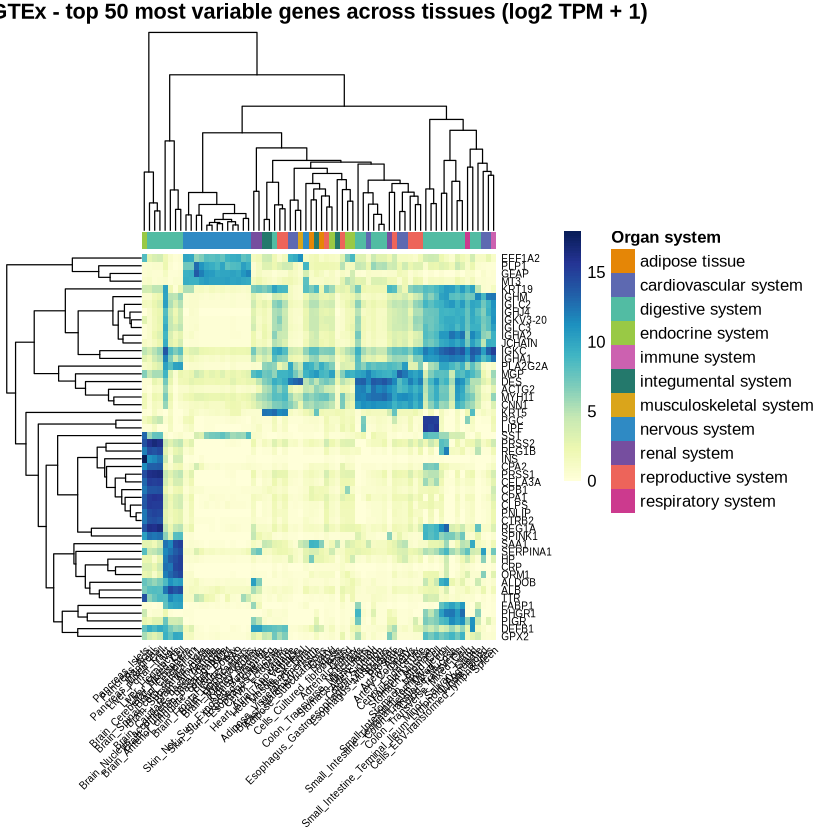

In [20]:
# Same two heatmaps, but on log2(x + 1)-transformed values: top-50 variance
# genes/proteins are reselected on the log2 matrix (not the raw top-50 list),
# and plotted on a linear color scale since the values are already log2.
top_variable_heatmap(
  gtex_log,
  "GTEx - top 50 most variable genes across tissues (log2 TPM + 1)",
  "gtex_top50_variable_clustermap_log_R.png",
  ann_col = tissue_annotation_df(colnames(gtex_log), "GTEx"),
  ann_colors = tissue_annotation_colors(colnames(gtex_log), "GTEx"),
  value_label = "log2(TPM + 1)",
  log_norm = FALSE,
  out_dir = GTEX_OUT
)

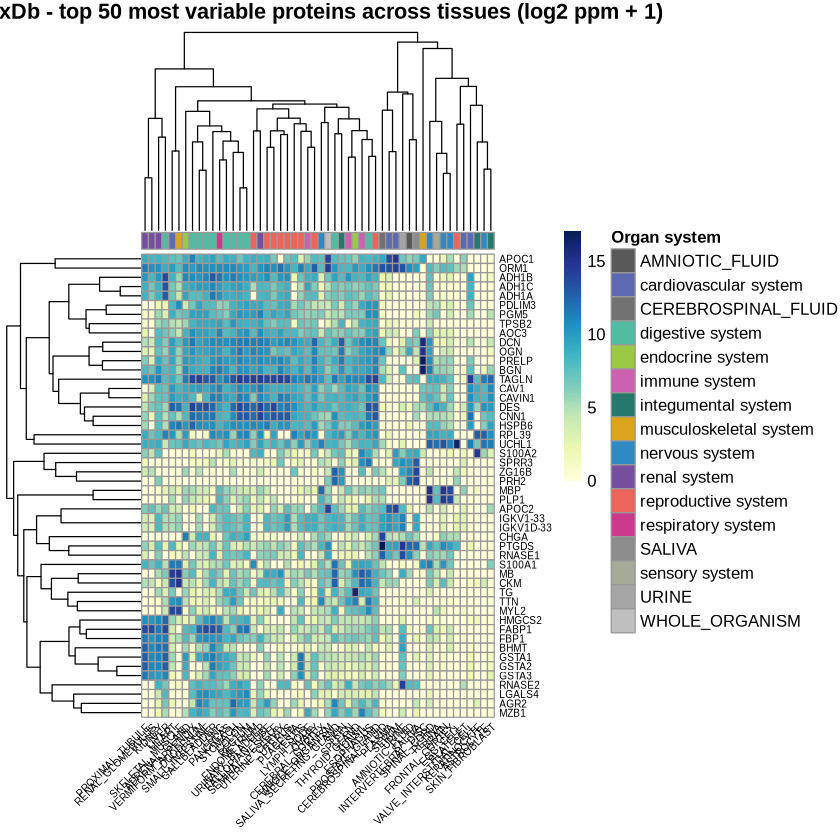

In [15]:
top_variable_heatmap(
  paxdb_log,
  "PaxDb - top 50 most variable proteins across tissues (log2 ppm + 1)",
  "paxdb_top50_variable_clustermap_log_R.png",
  ann_col = tissue_annotation_df(colnames(paxdb_log), "PaxDB"),
  ann_colors = tissue_annotation_colors(colnames(paxdb_log), "PaxDB"),
  value_label = "log2(ppm + 1)",
  log_norm = FALSE,
  out_dir = PAXDB_OUT
)

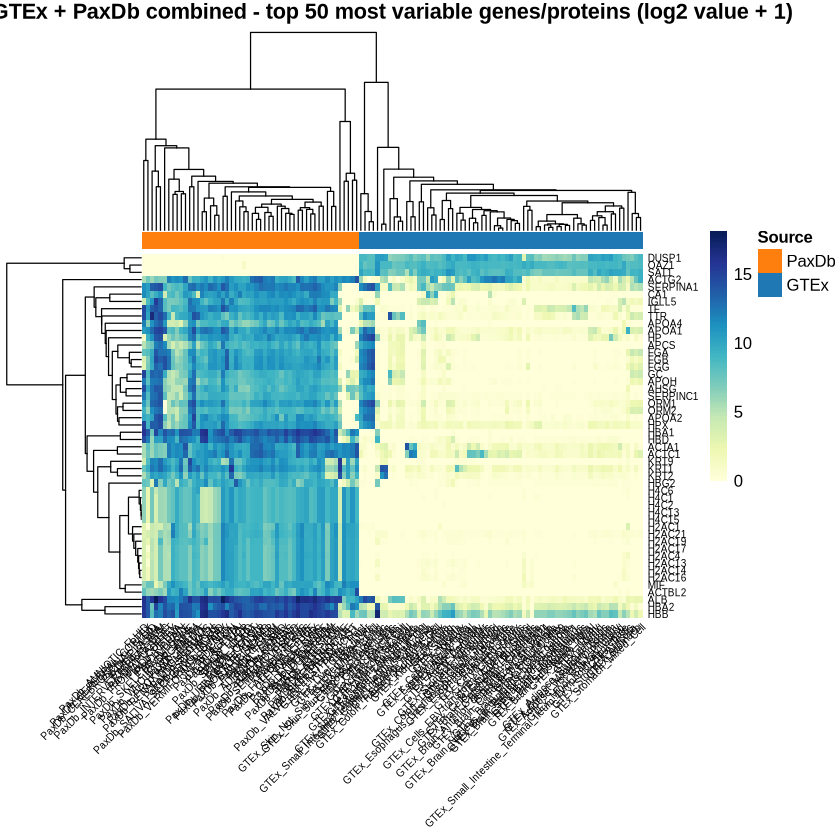

In [16]:
# Combined GTEx + PaxDb: join on shared genes (all tissues, prefixed by
# source), log2-transform, then reselect the top-50 variable rows within the
# joined log2 matrix (not a union of the two individual top-50 lists).
gtex_prefixed  <- gtex_mat
paxdb_prefixed <- paxdb_mat
colnames(gtex_prefixed)  <- paste0("GTEx_", colnames(gtex_prefixed))
colnames(paxdb_prefixed) <- paste0("PaxDb_", colnames(paxdb_prefixed))

shared_genes  <- intersect(rownames(paxdb_prefixed), rownames(gtex_prefixed))
combined_mat  <- cbind(paxdb_prefixed[shared_genes, ], gtex_prefixed[shared_genes, ])
combined_log  <- log2(combined_mat + 1)

source_of <- ifelse(startsWith(colnames(combined_log), "PaxDb_"), "PaxDb", "GTEx")
source_ann_col <- data.frame(
  Source = source_of, row.names = colnames(combined_log), check.names = FALSE
)

top_variable_heatmap(
  combined_log,
  "GTEx + PaxDb combined - top 50 most variable genes/proteins (log2 value + 1)",
  "combined_top50_variable_clustermap_R.png",
  ann_col = source_ann_col,
  ann_colors = list(Source = SOURCE_COLORS),
  value_label = "log2(value + 1)",
  log_norm = FALSE
)

## TCGA: top 50 most variable genes, hierarchically clustered

Same analysis as above, applied to the per-cohort median-TPM matrix built
in the TCGA data-loading section, with columns annotated by tissue of
origin instead of GTEx/PaxDb tissue.

`exclude_mito`'s default `mito_pattern = "^MT-"` matches gene *symbols*
(`MT-ND1`, ...) and never matches TCGA's Ensembl-ID rownames, so without
an override it would silently stop excluding mitochondrial genes here —
they are extremely highly expressed and highly variable across cohorts,
and would otherwise dominate the top-50 list. `TCGA_MT_ENSEMBL_IDS` is
the fixed set of GRCh38 Ensembl IDs for the 13 mitochondrial
protein-coding genes, passed in as an explicit `mito_pattern` instead.

Combining TCGA into the GTEx+PaxDb heatmap above isn't done here since
that join is keyed by gene symbol and TCGA rows are still Ensembl IDs —
see the ID-space mapping TODO in `CLAUDE.md`.

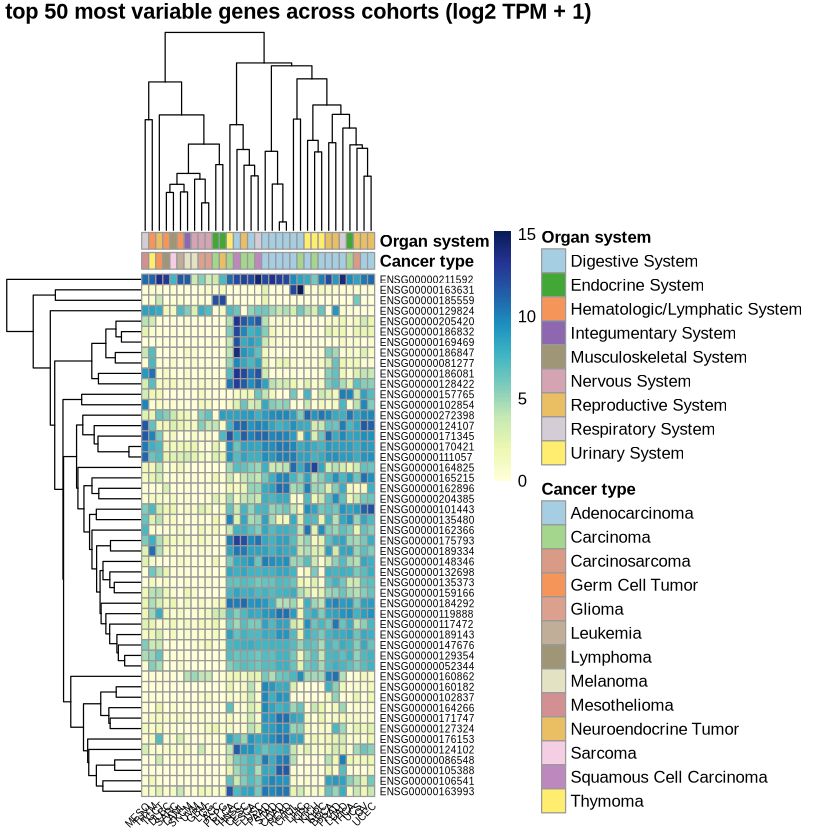

In [21]:
# GRCh38 Ensembl IDs of the 13 mitochondrial protein-coding genes.
TCGA_MT_ENSEMBL_IDS <- c(
  "ENSG00000198888", "ENSG00000198763", "ENSG00000198804", "ENSG00000198712",
  "ENSG00000228253", "ENSG00000198899", "ENSG00000198938", "ENSG00000198840",
  "ENSG00000212907", "ENSG00000198886", "ENSG00000198786", "ENSG00000198695",
  "ENSG00000198727"
)
tcga_mito_pattern <- paste0("^(", paste(TCGA_MT_ENSEMBL_IDS, collapse = "|"), ")$")



top_variable_heatmap(
  tcga_log,
  "TCGA - top 50 most variable genes across cohorts (log2 TPM + 1)",
  "tcga_top50_variable_clustermap_log_R.png",
  ann_col = tcga_annotation_df(colnames(tcga_log)),
  ann_colors = tcga_annotation_colors(colnames(tcga_log)),
  value_label = "log2(TPM + 1)",
  log_norm = FALSE,
  mito_pattern = tcga_mito_pattern,
  out_dir = TCGA_OUT,
  show_annotation_names = TRUE
)

## Section 9: PCA of tissue profiles, colored by tissue group / organ system

R equivalent of Section 6 of `filtering_source_exploration.ipynb` (PCA of
each source's log-transformed tissue profiles), but colored with the same
two-tier UBERON tissue taxonomy used for the heatmap annotation strips
above (`tissue_group_name()` / `organ_group_colors` / `system_group_colors`)
instead of that notebook's ad-hoc leading-token grouping, so tissue
groupings are consistent across every plot in this notebook. For each
source, both colorings of the same PCA are placed side by side via
patchwork.

In [30]:
# One row per tissue (observations), one column per gene/protein (features);
# matches the log2 matrices already built above (gtex_log, paxdb_log).
pca_scores_for_source <- function(log_mat, source_name) {
  mat <- log_mat
  mat[is.na(mat)] <- 0
  data <- t(mat)
  keep <- apply(data, 2, function(col) sd(col) > 0)
  data <- data[, keep, drop = FALSE]

  pca <- prcomp(data, center = TRUE, scale. = FALSE)
  var_explained <- (pca$sdev^2 / sum(pca$sdev^2))[1:2]

  scores <- as.data.frame(pca$x[, 1:2])
  colnames(scores) <- c("PC1", "PC2")
  scores$tissue <- rownames(scores)
  scores[["Tissue group"]] <- tissue_group_name(scores$tissue, source_name, "organ")
  scores[["Organ system"]] <- tissue_group_name(scores$tissue, source_name, "system")
  attr(scores, "var_explained") <- var_explained
  scores
}

plot_pca_panel <- function(scores, color_col, color_map, subtitle) {
  var_explained <- attr(scores, "var_explained")
  ggplot(scores, aes(x = PC1, y = PC2, color = .data[[color_col]])) +
    geom_hline(yintercept = 0, color = "grey85", linewidth = 0.4) +
    geom_vline(xintercept = 0, color = "grey85", linewidth = 0.4) +
    geom_point(size = 2.8, alpha = 0.9) +
    scale_color_manual(values = color_map, name = color_col) +
    labs(
      x = sprintf("PC1 (%.1f%% variance)", var_explained[1] * 100),
      y = sprintf("PC2 (%.1f%% variance)", var_explained[2] * 100),
      subtitle = subtitle
    ) +
    theme_minimal(base_size = 12) +
    theme(
      panel.grid.minor = element_blank(),
      legend.key.size = unit(0.35, "cm"),
      legend.text = element_text(size = 7),
      legend.title = element_text(size = 8, face = "bold")
    ) +
    guides(color = guide_legend(ncol = 1, override.aes = list(size = 2.6)))
}

plot_source_pca_pair <- function(log_mat, source_name, title, out_file, out_dir) {
  scores <- pca_scores_for_source(log_mat, source_name)

  present_organ  <- sort(unique(scores[["Tissue group"]]))
  present_system <- sort(unique(scores[["Organ system"]]))

  p_organ  <- plot_pca_panel(scores, "Tissue group", organ_group_colors[present_organ], "Colored by tissue group")
  p_system <- plot_pca_panel(scores, "Organ system", system_group_colors[present_system], "Colored by organ system")

  combined <- (p_organ | p_system) +
    plot_annotation(title = title, theme = theme(plot.title = element_text(size = 16, face = "bold")))

  ggsave(file.path(out_dir, out_file), combined, width = 16, height = 6.5, dpi = 200)
  combined
}

In [ ]:
plot_source_pca_pair(
  gtex_log, "GTEx",
  "PCA of GTEx median TPM by tissue",
  "gtex_pca_tissue_groups_R.png",
  out_dir = GTEX_OUT
)

In [ ]:
plot_source_pca_pair(
  paxdb_log, "PaxDB",
  "PCA of PaxDb ppm by tissue",
  "paxdb_pca_tissue_groups_R.png",
  out_dir = PAXDB_OUT
)

## Section 10: Healthy lung (GTEx) vs LUAD (TCGA) — sample-level PCA in log2 space

Unlike Section 9 (per-tissue/per-cohort *median* profiles), this PCA runs
on individual samples: every healthy-lung GTEx sample in
`data/gene_tpm_adult_gtex_v11_lung.gct.gz` (raw linear TPM) against every
TCGA-LUAD tumor sample in `data/tcga_raw/TCGA-LUAD.star_tpm.tsv.gz`
(already log2(TPM + 1), per GDC convention — same file convention as the
other `data/tcga_raw/TCGA-*.star_tpm.tsv.gz` cohorts used above). Both are
joined on shared bare Ensembl gene IDs, same approach as the GTEx + TCGA
combined heatmap above, then PCA'd together in log2(TPM + 1) space so the
two groups can be compared directly on one plot.

In [19]:
# Collapses only the (rare) duplicate-ID rows by row-wise median; distinct
# rows are copied through directly rather than run through a blanket
# grouped aggregation over all ~60k genes. dplyr's group_by()+summarise(
# across(median)) was measured at ~100s for 20k rows x 500 cols on this kind
# of wide file (500+ samples) - it calls median() once per gene per sample
# regardless of whether that gene ever collides, which is what made this
# section take minutes. Duplicates are only a handful of rows in practice
# (GTEx: none, post version-strip; TCGA: the _PAR_Y genes), so this instead
# splits off just those rows and runs matrixStats::colMedians() on that tiny
# subset, leaving the rest as a direct matrix slice.
collapse_duplicate_rows_median <- function(mat, ids) {
  if (!anyDuplicated(ids)) {
    rownames(mat) <- ids
    return(mat)
  }
  dup_ids <- unique(ids[duplicated(ids)])
  is_dup  <- ids %in% dup_ids

  unique_part <- mat[!is_dup, , drop = FALSE]
  rownames(unique_part) <- ids[!is_dup]

  dup_part <- t(sapply(dup_ids, function(id) {
    colMedians(mat[ids == id, , drop = FALSE], na.rm = TRUE)
  }))
  rownames(dup_part) <- dup_ids
  colnames(dup_part) <- colnames(mat)

  rbind(unique_part, dup_part)
}

In [20]:
GTEX_LUNG_SAMPLES_FILE <- file.path(REPO_ROOT, "data", "gene_tpm_adult_gtex_v11_lung.gct.gz")
LUAD_RAW_FILE <- file.path(TCGA_RAW_DIR, "TCGA-LUAD.star_tpm.tsv.gz")

# Per-sample counterpart of read_gtex_median_tpm_ensembl(): same Ensembl-ID
# keying and version-stripping, but collapses duplicate IDs across samples
# instead of collapsing samples into a tissue median. fread (vs. read_tsv)
# parses this ~500-column file noticeably faster too.
read_gtex_samples_ensembl <- function(path) {
  # fread reads .gz natively - no external zcat process, and a much
  # clearer error than fread(cmd=) gives if the path is simply wrong.
  dt <- fread(path, skip = 2, header = TRUE)
  sample_cols <- setdiff(colnames(dt), c("Name", "Description"))
  ids <- sub("\\..*$", "", dt$Name)
  mat <- as.matrix(dt[, ..sample_cols])
  collapse_duplicate_rows_median(mat, ids)
}

gtex_lung_samples_mat <- read_gtex_samples_ensembl(GTEX_LUNG_SAMPLES_FILE)
gtex_lung_samples_log <- log2(gtex_lung_samples_mat + 1)

ERROR: Error in fread(path, skip = 2, header = TRUE): To read gz files directly, fread() requires 'R.utils' package which cannot be found. Please install 'R.utils' using 'install.packages('R.utils')'.


In [28]:
# Per-sample counterpart of read_tcga_cohort_median_log(): same version- and
# PAR_Y-duplicate handling, but keeps every sample column instead of
# collapsing to one cohort-median column. Values are already log2(TPM + 1).
read_tcga_cohort_samples_log <- function(path) {
  dt <- fread(path, header = TRUE)  # native .gz support, see read_gtex_samples_ensembl()
  sample_cols <- colnames(dt)[-1]
  ids <- sub("\\..*$", "", dt[[1]])          # drop Ensembl version / _PAR_Y suffix
  mat <- as.matrix(dt[, ..sample_cols])
  collapse_duplicate_rows_median(mat, ids)
}

luad_samples_log <- read_tcga_cohort_samples_log(LUAD_RAW_FILE)

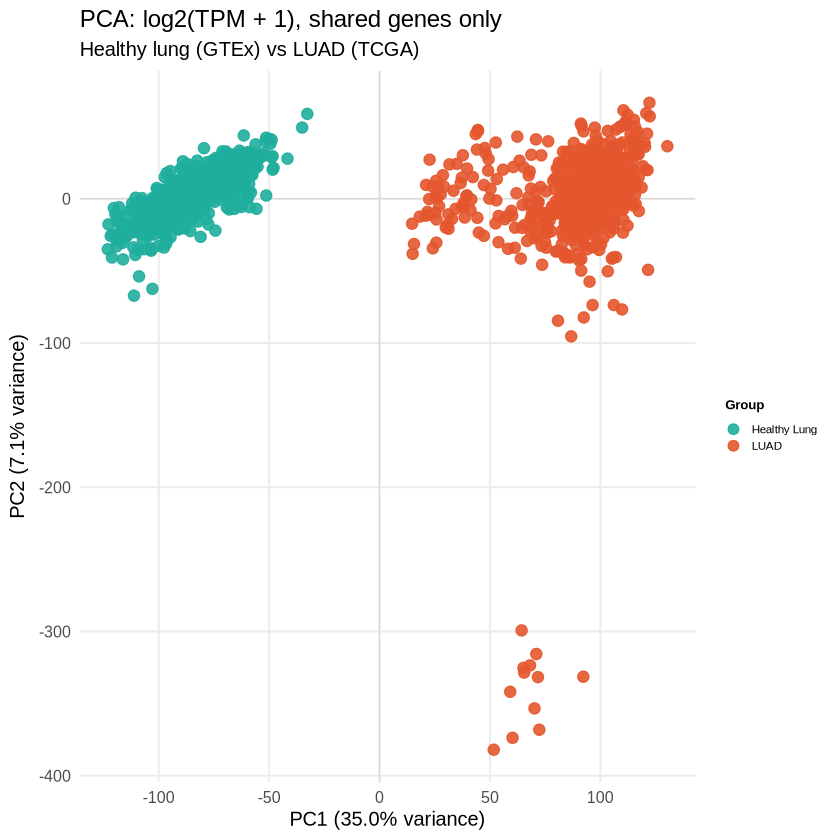

In [43]:
# Join on shared Ensembl genes (prefixed by group), same pattern as the
# combined heatmaps above.
gtex_lung_prefixed <- gtex_lung_samples_log
colnames(gtex_lung_prefixed) <- paste0("Healthy_Lung_", colnames(gtex_lung_prefixed))

luad_prefixed <- luad_samples_log
colnames(luad_prefixed) <- paste0("LUAD_", colnames(luad_prefixed))

shared_genes_lung_luad <- intersect(rownames(gtex_lung_prefixed), rownames(luad_prefixed))
lung_luad_log <- cbind(
  gtex_lung_prefixed[shared_genes_lung_luad, ],
  luad_prefixed[shared_genes_lung_luad, ]
)

lung_luad_group <- ifelse(startsWith(colnames(lung_luad_log), "LUAD_"), "LUAD", "Healthy Lung")
LUNG_LUAD_COLORS <- c("Healthy Lung" = "#1FAE9D", "LUAD" = "#E4572E")

# Same PCA construction as pca_scores_for_source() in Section 9 (samples as
# observations, zero-variance genes dropped, centered but not scaled), just
# grouped by Healthy Lung / LUAD instead of by tissue/organ-system.
pca_lung_luad <- function(log_mat, group) {
  mat <- log_mat
  mat[is.na(mat)] <- 0
  data <- t(mat)
  keep <- apply(data, 2, function(col) sd(col) > 0)
  data <- data[, keep, drop = FALSE]

  pca <- prcomp(data, center = TRUE, scale. = FALSE)
  var_explained <- (pca$sdev^2 / sum(pca$sdev^2))[1:2]

  scores <- as.data.frame(pca$x[, 1:2])
  colnames(scores) <- c("PC1", "PC2")
  scores$Group <- group
  attr(scores, "var_explained") <- var_explained
  scores
}

lung_luad_scores <- pca_lung_luad(lung_luad_log, lung_luad_group)

# Reuses plot_pca_panel() from Section 9 - it only needs a "var_explained"
# attribute and a grouping column, both of which pca_lung_luad() provides.
p_lung_luad_pca <- plot_pca_panel(
  lung_luad_scores, "Group", LUNG_LUAD_COLORS, "Healthy lung (GTEx) vs LUAD (TCGA)"
) +
  ggtitle("PCA: log2(TPM + 1), shared genes only")

ggsave(file.path(OUT_ROOT, "gtex_lung_vs_tcga_luad_pca_R.png"), p_lung_luad_pca, width = 8, height = 6.5, dpi = 200)
p_lung_luad_pca

## Section 11: Gene-set overlap — GTEx-normal-lung vs. TCGA-LUAD "expressed" genes

"Expressed" = median TPM > `EXPRESSION_THRESHOLD` across samples, computed
independently for GTEx-normal lung (`gtex_lung_samples_mat`, linear TPM)
and TCGA-LUAD tumor (`luad_samples_log`, already log2(TPM + 1)) from
Section 10. The TCGA side applies the threshold in log2 space
(`log2(EXPRESSION_THRESHOLD + 1)`) rather than exponentiating every value
back to linear TPM first — valid since median commutes with any monotonic
transform, the same reasoning already used when building `tcga_log` above.
Both expressed-gene sets are restricted to `shared_genes_lung_luad`
(Section 10) so "not expressed" isn't confounded with "absent from that
platform's gene set".

The genes expressed in TCGA-LUAD but *not* GTEx-normal lung are exactly
the ones a GTEx-based expression filter would wrongly discard for a
lung-cancer disease module - the direct motivating case for filtering on
disease-matched, not just tissue-matched, expression data.

In [17]:
EXPRESSION_THRESHOLD <- 2 # TPM

gtex_lung_median_tpm <- rowMedians(gtex_lung_samples_mat, na.rm = TRUE)
names(gtex_lung_median_tpm) <- rownames(gtex_lung_samples_mat)

luad_median_log <- rowMedians(luad_samples_log, na.rm = TRUE)
names(luad_median_log) <- rownames(luad_samples_log)

luad_log_threshold <- log2(EXPRESSION_THRESHOLD + 1)

expressed_gtex_lung <- names(gtex_lung_median_tpm)[gtex_lung_median_tpm > EXPRESSION_THRESHOLD]
expressed_luad      <- names(luad_median_log)[luad_median_log > luad_log_threshold]

expressed_gtex_lung <- intersect(expressed_gtex_lung, shared_genes_lung_luad)
expressed_luad      <- intersect(expressed_luad, shared_genes_lung_luad)

cat(sprintf(
  "Expressed (median TPM > %.0f): %d/%d GTEx-normal-lung genes, %d/%d TCGA-LUAD genes\n",
  EXPRESSION_THRESHOLD,
  length(expressed_gtex_lung), length(shared_genes_lung_luad),
  length(expressed_luad), length(shared_genes_lung_luad)
))

ERROR: Error: object 'gtex_lung_samples_mat' not found


NULL

pdf 
  2

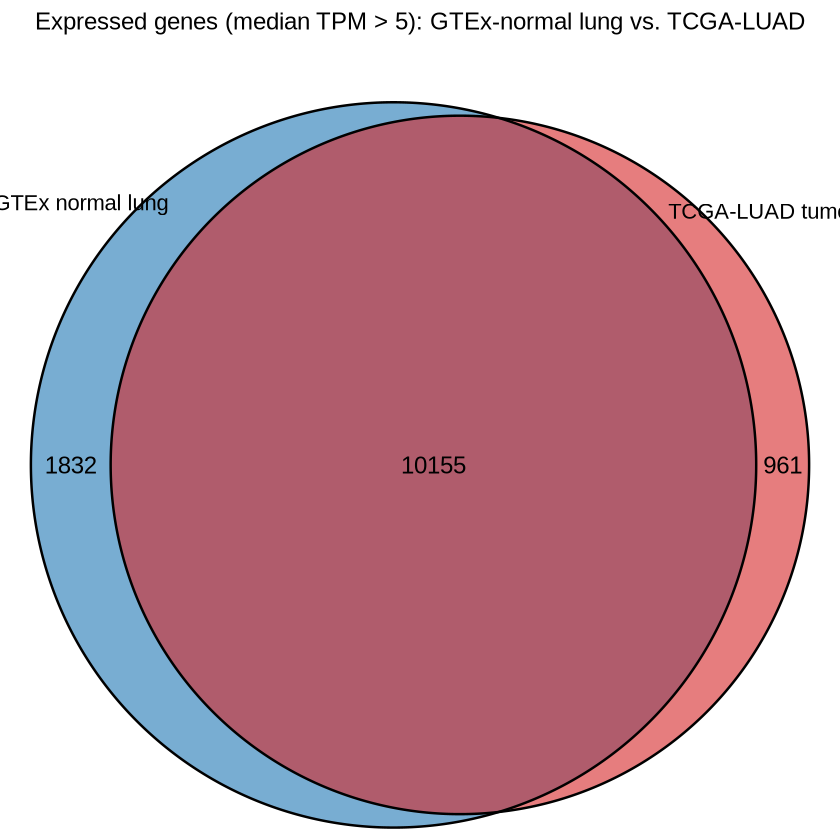

In [51]:
# VennDiagram writes an INFO line to a log file by default; drop it to
# ERROR so re-running this cell doesn't litter the working directory.
suppressMessages(futile.logger::flog.threshold(futile.logger::ERROR, name = "VennDiagramLogger"))

venn_gene_sets <- list(
  "GTEx normal lung" = expressed_gtex_lung,
  "TCGA-LUAD tumor"  = expressed_luad
)

venn_plot <- VennDiagram::venn.diagram(
  x = venn_gene_sets,
  filename = NULL,
  fill = c(SOURCE_COLORS[["GTEx"]], "#D62728"),
  alpha = 0.6,
  cat.cex = 1.1,
  cex = 1.2,
  main = sprintf("Expressed genes (median TPM > %.0f): GTEx-normal lung vs. TCGA-LUAD", EXPRESSION_THRESHOLD),
  main.cex = 1.2,
  fontfamily = "sans",
  cat.fontfamily = "sans",
  main.fontfamily = "sans"
)

png(file.path(OUT_ROOT, "gtex_lung_vs_tcga_luad_expressed_venn_R.png"), width = 8, height = 7, units = "in", res = 200)
grid.newpage()
grid.draw(venn_plot)
dev.off()

grid.newpage()
grid.draw(venn_plot)

In [46]:
tcga_only_genes <- setdiff(expressed_luad, expressed_gtex_lung)
cat(sprintf(
  "%d genes expressed in TCGA-LUAD but not GTEx-normal lung (median TPM > %.0f) - would be wrongly discarded by a GTEx-only filter\n",
  length(tcga_only_genes), EXPRESSION_THRESHOLD
))

write_tsv(tibble(ensembl = tcga_only_genes), file.path(OUT_ROOT, "tcga_luad_only_expressed_genes.tsv"))
head(tcga_only_genes, 20)

961 genes expressed in TCGA-LUAD but not GTEx-normal lung (median TPM > 5) - would be wrongly discarded by a GTEx-only filter


[1] "ENSG00000002587" "ENSG00000003249" "ENSG00000006432" "ENSG00000006555"
 [5] "ENSG00000006695" "ENSG00000006747" "ENSG00000008323" "ENSG00000010072"
 [9] "ENSG00000010704" "ENSG00000011347" "ENSG00000011376" "ENSG00000011426"
[13] "ENSG00000012174" "ENSG00000014257" "ENSG00000016391" "ENSG00000019186"
[17] "ENSG00000020256" "ENSG00000029153" "ENSG00000034533" "ENSG00000040275"

## Section 12: Cancer-only expressed genes across all 33 TCGA cohorts (bar plot)

Extends the single-cohort version above to every TCGA cohort in
`TCGA_COHORT_TISSUE` (cell `6cedbf6d`), each compared against its matched
healthy GTEx tissue from the wide, all-tissue matrix (`gtex_wide_mat_ensembl`,
built below from `EXPR_FILE`).

GTEx's 54 tissues don't cover every TCGA cohort's tissue of origin - there's
no GTEx bile duct, lymph node, pleura, soft-tissue, thymus, or eye sample at
all, and a few matches are deliberately imperfect proxies (Whole Blood for
bone marrow/LAML, Colon - Sigmoid for rectum/READ). Cohorts with no
defensible match are excluded rather than forced onto a misleading
reference; `TCGA_COHORT_GTEX_TISSUE` below documents every choice and `NA`.

This reads all ~26 usable cohorts' raw per-sample files from
`TCGA_RAW_DIR`, so - like the original "Data loading — TCGA" section above -
expect this to take a while; consider running it via `sbatch` rather than
directly on the login node.

In [78]:
# Ensembl-keyed counterpart of gtex_mat (which is keyed by symbol), needed
# to compare directly against TCGA's Ensembl-keyed cohort matrices. Reuses
# collapse_duplicate_rows_median() from Section 10 - GTEx IDs are already
# unique before the version is stripped, so in practice this just renames
# rows rather than actually aggregating anything.
read_gtex_median_tpm_ensembl <- function(path) {
  dt <- fread(path, skip = 2, header = TRUE)
  tissue_cols <- setdiff(colnames(dt), c("Name", "Description"))
  ids <- sub("\\..*$", "", dt$Name)
  mat <- as.matrix(dt[, ..tissue_cols])
  collapse_duplicate_rows_median(mat, ids)
}

gtex_wide_mat_ensembl <- read_gtex_median_tpm_ensembl(EXPR_FILE)

In [79]:
# TCGA cohort code -> matched GTEx tissue column name in gtex_wide_mat_ensembl.
# Names taken from the real header of data/expression_by_tissue.gct - GTEx
# tissue names there are underscore-separated (e.g. "Brain_Cortex",
# "Colon_Sigmoid"), not the "Tissue - Subregion" format assumed earlier.
#
# Cohorts with no defensible GTEx tissue of origin are omitted entirely
# rather than forced onto a misleading reference:
#   CHOL - no bile duct sample
#   DLBC - no lymph node sample (Spleen is not a defensible proxy)
#   HNSC - no oral cavity/pharynx/larynx mucosa (Minor_Salivary_Gland is
#          anatomically close but histologically a poor match - glandular,
#          not the squamous epithelium HNSC mostly arises from)
#   MESO - no pleura sample
#   SARC - too histologically heterogeneous (muscle/fat/fibrous origin) for
#          any single GTEx tissue, even though Muscle_Skeletal exists
#   THYM - no thymus sample
#   UVM  - no eye sample
TCGA_COHORT_GTEX_TISSUE <- c(
  ACC  = "Adrenal_Gland",
  BLCA = "Bladder",
  BRCA = "Breast_Mammary_Tissue",
  CESC = "Cervix_Ectocervix",
  COAD = "Colon_Sigmoid",
  ESCA = "Esophagus_Mucosa",
  GBM  = "Brain_Cortex",              # supratentorial tumor -> cortex, not e.g. cerebellum
  KICH = "Kidney_Cortex",             # renal cell carcinomas arise from cortex, not medulla
  KIRC = "Kidney_Cortex",
  KIRP = "Kidney_Cortex",
  LAML = "Whole_Blood",               # proxy: closest available hematologic reference to bone marrow
  LGG  = "Brain_Cortex",
  LIHC = "Liver",
  LUAD = "Lung",
  LUSC = "Lung",
  OV   = "Ovary",
  PAAD = "Pancreas",
  PCPG = "Adrenal_Gland",
  PRAD = "Prostate",
  READ = "Colon_Sigmoid",             # proxy: rectal adenocarcinoma shares colon mucosal biology
  SKCM = "Skin_Sun_Exposed_Lower_leg",
  STAD = "Stomach",
  TGCT = "Testis",
  THCA = "Thyroid",
  UCEC = "Uterus",
  UCS  = "Uterus"
)

excluded_cohorts <- setdiff(names(TCGA_COHORT_TISSUE), names(TCGA_COHORT_GTEX_TISSUE))
usable_cohorts <- names(TCGA_COHORT_GTEX_TISSUE)
cat(sprintf(
  "Using %d/%d TCGA cohorts with a matched GTEx tissue; excluded: %s\n",
  length(usable_cohorts), length(TCGA_COHORT_TISSUE), paste(excluded_cohorts, collapse = ", ")
))

Using 26/33 TCGA cohorts with a matched GTEx tissue; excluded: CHOL, DLBC, HNSC, MESO, SARC, THYM, UVM


In [80]:
# healthy side: a single already-median-per-tissue column from the wide
# matrix, so no per-sample aggregation is needed.
expressed_from_tissue_column <- function(values, threshold, universe) {
  intersect(names(values)[values > threshold], universe)
}

# tumor side: per-sample log2(TPM + 1) matrix -> median per gene, threshold
# applied as the equivalent log2(threshold + 1) cutoff (median commutes with
# any monotonic transform - same reasoning as Section 11).
expressed_from_log2 <- function(log_mat, threshold, universe) {
  log_threshold <- log2(threshold + 1)
  med <- rowMedians(log_mat, na.rm = TRUE)
  names(med) <- rownames(log_mat)
  intersect(names(med)[med > log_threshold], universe)
}

cancer_only_rows <- lapply(usable_cohorts, function(cohort) {
  healthy_tissue <- TCGA_COHORT_GTEX_TISSUE[[cohort]]
  cohort_file <- file.path(TCGA_RAW_DIR, sprintf("TCGA-%s.star_tpm.tsv.gz", cohort))
  cancer_log <- read_tcga_cohort_samples_log(cohort_file)

  healthy_col <- gtex_wide_mat_ensembl[, healthy_tissue]
  universe <- intersect(names(healthy_col), rownames(cancer_log))

  healthy_expressed <- expressed_from_tissue_column(healthy_col, EXPRESSION_THRESHOLD, universe)
  cancer_expressed  <- expressed_from_log2(cancer_log, EXPRESSION_THRESHOLD, universe)
  cancer_only <- setdiff(cancer_expressed, healthy_expressed)

  tibble(cancer = cohort, healthy_tissue = healthy_tissue, n_cancer_only = length(cancer_only))
})
cancer_only_counts <- bind_rows(cancer_only_rows)
cancer_only_counts

cancer,healthy_tissue,n_cancer_only
<chr>,<chr>,<int>
ACC,Adrenal_Gland,857
BLCA,Bladder,1253
BRCA,Breast_Mammary_Tissue,1664
CESC,Cervix_Ectocervix,1201
COAD,Colon_Sigmoid,2077
ESCA,Esophagus_Mucosa,2450
GBM,Brain_Cortex,3365
KICH,Kidney_Cortex,1449
KIRC,Kidney_Cortex,2529


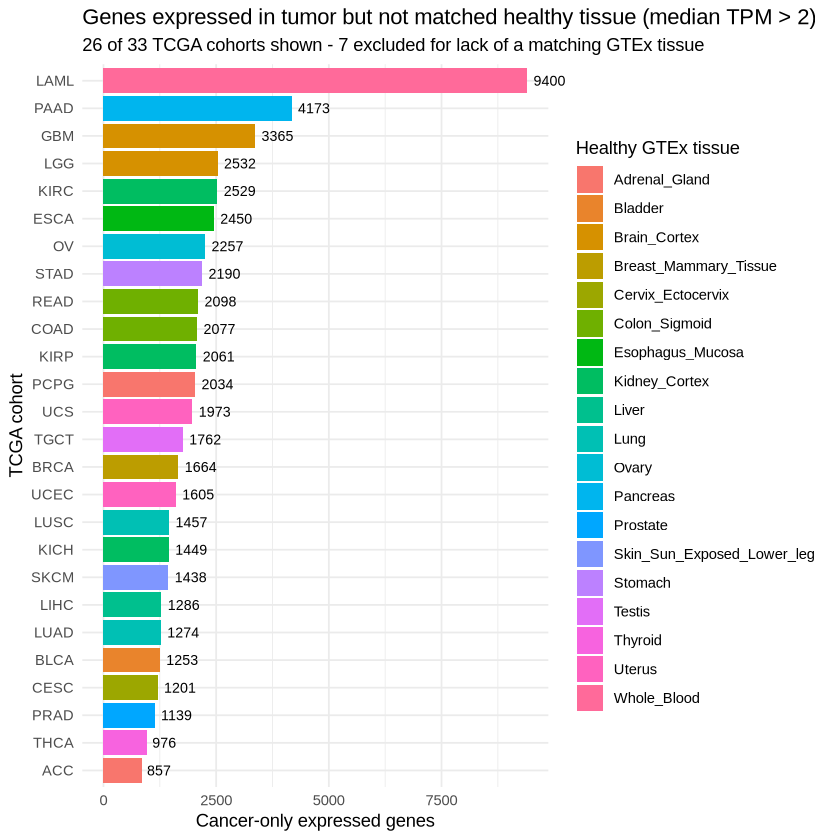

In [81]:
p_cancer_only <- ggplot(cancer_only_counts, aes(x = reorder(cancer, n_cancer_only), y = n_cancer_only, fill = healthy_tissue)) +
  geom_col() +
  geom_text(aes(label = n_cancer_only), hjust = -0.2, size = 3) +
  coord_flip(clip = "off") +
  labs(
    title = sprintf("Genes expressed in tumor but not matched healthy tissue (median TPM > %d)", EXPRESSION_THRESHOLD),
    subtitle = sprintf("%d of 33 TCGA cohorts shown - %d excluded for lack of a matching GTEx tissue",
                        length(usable_cohorts), length(excluded_cohorts)),
    x = "TCGA cohort", y = "Cancer-only expressed genes", fill = "Healthy GTEx tissue"
  ) +
  theme_minimal(base_size = 11) +
  theme(legend.position = "right")

ggsave(file.path(OUT_ROOT, "cancer_only_expressed_genes_barplot_all_cohorts_R.png"), p_cancer_only, width = 10, height = 10, dpi = 200)
p_cancer_only

## Section 13: Expressed genes per organ group — GTEx vs. PaxDB (bar plot)

Unlike Section 12 (set difference / "only in X"), this shows both sources'
expressed-gene counts side by side per organ group, using the wide
multi-tissue matrices already loaded in Section 8 (`gtex_mat`, `paxdb_mat`)
rather than per-cohort raw files.

GTEx and PaxDB use different tissue-naming vocabularies (e.g. GTEx's 13
`Brain_*` subregions vs. PaxDB's own brain tissue names), so tissues are
matched via the UBERON organ-level grouping already built in the "Tissue
grouping" section above (`tissue_group_name()`), rather than a new
hand-built lookup table like Section 12 needed for TCGA. A gene counts as
"expressed" for an organ group if it clears the threshold in *any* tissue
column belonging to that group, in either source; only organ groups with
at least one tissue from both GTEx and PaxDB are shown, and only genes in
the shared GTEx/PaxDB gene universe (same symbol-keyed join as the
"Combined GTEx + PaxDb" heatmap in Section 8) are counted.

Thresholds are **not the same number** across sources - TPM and ppm are
different scales entirely (ppm is bounded at 1,000,000 by definition, and a
typical housekeeping protein sits in the thousands). GTEx keeps
`EXPRESSION_THRESHOLD` (TPM > 2, Section 11); PaxDB uses
`PAXDB_EXPRESSION_THRESHOLD` (ppm > 1).

In [21]:
PAXDB_EXPRESSION_THRESHOLD <- 1  # ppm
EPRESSION_THREHOLD <- 2

shared_genes_gtex_paxdb <- intersect(rownames(gtex_mat), rownames(paxdb_mat))

gtex_organ_group  <- tissue_group_name(colnames(gtex_mat), "GTEx", "organ")
paxdb_organ_group <- tissue_group_name(colnames(paxdb_mat), "PaxDB", "organ")

shared_organ_groups <- intersect(unique(gtex_organ_group), unique(paxdb_organ_group))

cat(sprintf(
  "%d shared genes, %d organ groups present in both GTEx and PaxDB\n",
  length(shared_genes_gtex_paxdb), length(shared_organ_groups)
))

18749 shared genes, 25 organ groups present in both GTEx and PaxDB


In [22]:
# "Expressed" for an organ group = exceeds threshold in *any* tissue column
# belonging to that group (a gene only needs to be detected in one brain
# subregion to count as "expressed in brain", not all of them).
expressed_any_column <- function(mat, cols, threshold, universe) {
  sub <- mat[universe, cols, drop = FALSE]
  rows_expressed <- apply(sub, 1, function(x) any(x > threshold, na.rm = TRUE))
  universe[rows_expressed]
}

organ_group_counts <- lapply(shared_organ_groups, function(grp) {
  gtex_cols  <- colnames(gtex_mat)[gtex_organ_group == grp]
  paxdb_cols <- colnames(paxdb_mat)[paxdb_organ_group == grp]

  n_gtex  <- length(expressed_any_column(gtex_mat, gtex_cols, EXPRESSION_THRESHOLD, shared_genes_gtex_paxdb))
  n_paxdb <- length(expressed_any_column(paxdb_mat, paxdb_cols, PAXDB_EXPRESSION_THRESHOLD, shared_genes_gtex_paxdb))

  bind_rows(
    tibble(organ_group = grp, source = "GTEx",  n_expressed = n_gtex),
    tibble(organ_group = grp, source = "PaxDB", n_expressed = n_paxdb)
  )
})
organ_group_counts <- bind_rows(organ_group_counts)
organ_group_counts

organ_group,source,n_expressed
<chr>,<chr>,<int>
adrenal gland,GTEx,11417
adrenal gland,PaxDB,7063
urinary bladder,GTEx,12324
urinary bladder,PaxDB,6663
brain,GTEx,13506
brain,PaxDB,10995
spinal cord,GTEx,11685
spinal cord,PaxDB,6205
skin of body,GTEx,13010


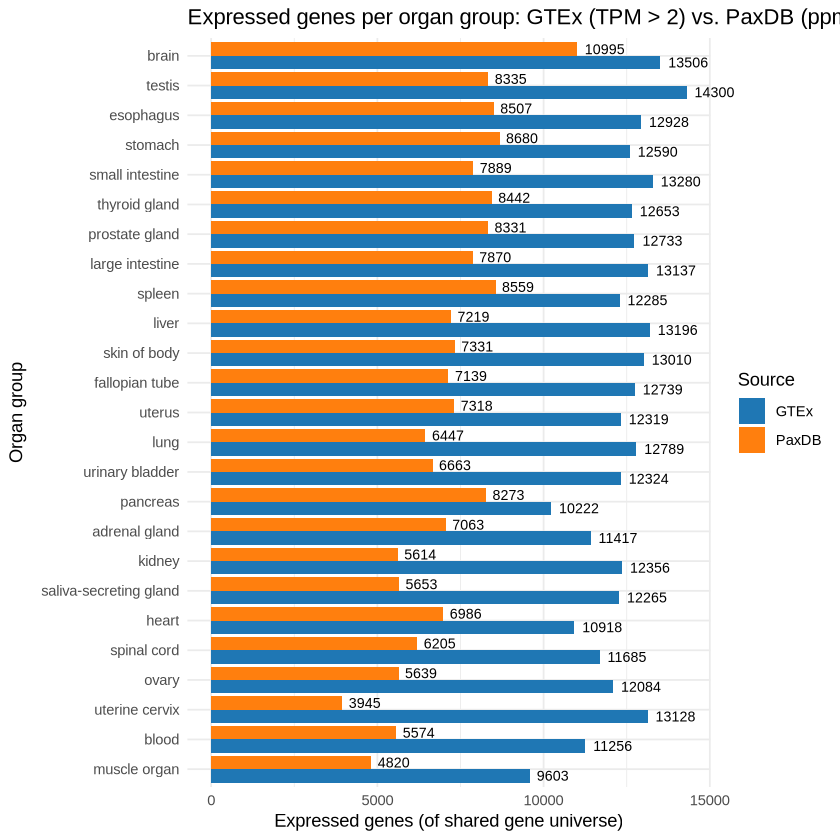

In [23]:
p_gtex_vs_paxdb <- ggplot(organ_group_counts, aes(x = reorder(organ_group, n_expressed, sum), y = n_expressed, fill = source)) +
  geom_col(position = "dodge") +
  geom_text(aes(label = n_expressed), position = position_dodge(width = 0.9), hjust = -0.2, size = 3) +
  coord_flip(clip = "off") +
  scale_fill_manual(values = c(GTEx = SOURCE_COLORS[["GTEx"]], PaxDB = SOURCE_COLORS[["PaxDb"]])) +
  labs(
    title = sprintf("Expressed genes per organ group: GTEx (TPM > %d) vs. PaxDB (ppm > %d)",
                     EXPRESSION_THRESHOLD, PAXDB_EXPRESSION_THRESHOLD),
    x = "Organ group", y = "Expressed genes (of shared gene universe)", fill = "Source"
  ) +
  theme_minimal(base_size = 11)

ggsave(file.path(OUT_ROOT, "gtex_vs_paxdb_expressed_barplot_R.png"), p_gtex_vs_paxdb, width = 9, height = 7, dpi = 200)
p_gtex_vs_paxdb